# CKG Reasoner v2 — D3 Dengue (n=1,018) Frozen External Validation

**Purpose:** additional frozen-CKG validation using the existing CKG Reasoner v2 Dengue knowledge representation.

**Protocol:** outcome labels are retained only for retrospective external evaluation. They are not used to construct the CKG representation, fit K-means, estimate centroids, tune the reasoner, or select K. The primary clustering representation is the full four-dimensional post-KG vector `variables=None` = `[P_evidence, r, c, Confidence_Score]`.

**Important:** inspect the `hmap_report()` before interpreting results. Dataset-specific variables that cannot be mapped to an existing Dengue EFN are intentionally left unused rather than changing the frozen knowledge representation.

## 0. Reproducibility configuration

In [7]:
# Frozen-validation configuration
DISEASE = "Dengue"
TARGET = "Outcome"
RANDOM_STATE = 42
K_RANGE = range(2, 11)
CLUSTER_VARIABLES = ["P_evidence", "r", "c", "Confidence_Score"]
BOOTSTRAP_N = 1000
WITHHOLD_FRACTIONS = [0.10, 0.25, 0.50]
SEEDS = list(range(20))

# K is deliberately NOT chosen from outcome performance.
# It will be selected below from the internal label-free K-means diagnostics.
BASELINE_K = None

print("Disease:", DISEASE)
print("Target:", TARGET)
print("Baseline clustering variables:", CLUSTER_VARIABLES)
print("K selection: label-free internal diagnostic only")

Disease: Dengue
Target: Outcome
Baseline clustering variables: ['P_evidence', 'r', 'c', 'Confidence_Score']
K selection: label-free internal diagnostic only


## 1. Colab / package setup

In [8]:
from google.colab import drive
drive.mount("/content/drive", force_remount=False)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import sys
import os
import importlib

# ============================================================
# CKG REASONER — COLAB SOURCE SETUP + VALIDATION
# ============================================================

PACKAGE_PATH = "/content/drive/MyDrive/CKG/ckg_reasoner_package_v2"
SRC_PATH = os.path.join(PACKAGE_PATH, "src")
CKG_PATH = os.path.join(SRC_PATH, "ckg_reasoner")
DATA_PATH = os.path.join(CKG_PATH, "data")

print("=" * 70)
print("CKG REASONER — COLAB SOURCE SETUP")
print("=" * 70)

print("PACKAGE_PATH :", PACKAGE_PATH)
print("SRC_PATH     :", SRC_PATH)
print("CKG_PATH     :", CKG_PATH)

# ------------------------------------------------------------
# 1. Validate package structure
# ------------------------------------------------------------

required_directories = {
    "Package directory": PACKAGE_PATH,
    "Source directory": SRC_PATH,
    "CKG package directory": CKG_PATH,
}

for label, path in required_directories.items():
    exists = os.path.isdir(path)
    print(f"{label:<24}: {'OK' if exists else 'MISSING'}")

    if not exists:
        raise FileNotFoundError(
            f"{label} not found:\n{path}"
        )


required_files = [
    "__init__.py",
    "model.py",
    "reasoning.py",
    "knowledge.py",
]

missing_files = [
    filename
    for filename in required_files
    if not os.path.isfile(os.path.join(CKG_PATH, filename))
]

if missing_files:
    raise FileNotFoundError(
        "Required CKG package files are missing:\n"
        + "\n".join(f"  - {name}" for name in missing_files)
    )

print("\nRequired core package files: OK")


# ------------------------------------------------------------
# 2. Remove previously added CKG package paths
# ------------------------------------------------------------

old_paths = [
    p for p in sys.path
    if "ckg_reasoner_package" in str(p)
]

if old_paths:
    print("\nRemoving previous CKG source paths:")
    for p in old_paths:
        print("  ", p)

sys.path = [
    p for p in sys.path
    if "ckg_reasoner_package" not in str(p)
]


# ------------------------------------------------------------
# 3. Force the selected source directory to highest priority
# ------------------------------------------------------------

sys.path.insert(0, SRC_PATH)

print("\nActive source path:")
print(" ", sys.path[0])


# ------------------------------------------------------------
# 4. Remove stale imported CKG modules
# ------------------------------------------------------------

removed_modules = []

for name in list(sys.modules):
    if name == "ckg_reasoner" or name.startswith("ckg_reasoner."):
        removed_modules.append(name)
        del sys.modules[name]

if removed_modules:
    print("\nRemoved cached CKG modules:")
    for name in sorted(removed_modules):
        print("  ", name)
else:
    print("\nNo cached CKG modules found.")

importlib.invalidate_caches()


# ------------------------------------------------------------
# 5. Display package contents before import
# ------------------------------------------------------------

print("\n=== PACKAGE CONTENTS ===")

package_files = sorted(os.listdir(CKG_PATH))

for filename in package_files[:30]:
    print("  ", filename)

if len(package_files) > 30:
    print(f"  ... and {len(package_files) - 30} more")


# ------------------------------------------------------------
# 6. Import CKG Reasoner
# ------------------------------------------------------------

import ckg_reasoner
from ckg_reasoner import CKGModel


# ------------------------------------------------------------
# 7. Verify imported package
# ------------------------------------------------------------

print("\n=== IMPORT CHECK ===")

print("Imported from:")
print(" ", ckg_reasoner.__file__)

print("\nPackage path:")
for p in ckg_reasoner.__path__:
    print(" ", p)

CKG_VERSION = getattr(
    ckg_reasoner,
    "__version__",
    "NO VERSION"
)

print("\nVersion:", CKG_VERSION)
print(
    "CKGModel available:",
    hasattr(ckg_reasoner, "CKGModel")
)
print("CKGModel:", CKGModel)


# ------------------------------------------------------------
# 8. Safety check:
#    ensure Colab did not import another installed CKG package
# ------------------------------------------------------------

imported_file = os.path.realpath(ckg_reasoner.__file__)
expected_root = os.path.realpath(SRC_PATH)

try:
    common_root = os.path.commonpath(
        [imported_file, expected_root]
    )
except ValueError:
    common_root = ""

if common_root != expected_root:
    raise RuntimeError(
        "\nWRONG CKG PACKAGE IMPORTED!\n\n"
        f"Expected package under:\n{expected_root}\n\n"
        f"But imported:\n{imported_file}"
    )

print("\nSource-path verification: PASSED")


# ------------------------------------------------------------
# 9. Check important modules
# ------------------------------------------------------------

important_modules = [
    "condition_logic.py",
    "units.py",
    "function_policy.py",
    "functions.py",
    "clinical_transformer.py",
    "mapping.py",
    "retrieval.py",
    "reporting.py",
]

print("\n=== MODULE CHECK ===")

missing_modules = []

for filename in important_modules:
    path = os.path.join(CKG_PATH, filename)
    exists = os.path.isfile(path)

    print(
        f"{filename:<30}"
        f"{'OK' if exists else 'MISSING'}"
    )

    if not exists:
        missing_modules.append(filename)


# ------------------------------------------------------------
# 10. Check bundled knowledge/data files
# ------------------------------------------------------------

print("\n=== DATA / KNOWLEDGE CHECK ===")
print("Data directory:", DATA_PATH)
print(
    "Data directory exists:",
    os.path.isdir(DATA_PATH)
)

yaml_files = []

if os.path.isdir(DATA_PATH):

    for root, dirs, files in os.walk(DATA_PATH):

        for filename in files:

            if filename.lower().endswith(
                (".yaml", ".yml")
            ):
                yaml_files.append(
                    os.path.join(root, filename)
                )

    yaml_files = sorted(yaml_files)

    print("YAML/YML files found:", len(yaml_files))

    for path in yaml_files:
        print(
            "  ",
            os.path.relpath(path, CKG_PATH)
        )

else:
    print("WARNING: bundled data directory not found.")


# ------------------------------------------------------------
# 11. Final diagnostic summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CKG REASONER SETUP COMPLETED")
print("=" * 70)

print("Source       :", SRC_PATH)
print("Imported from:", ckg_reasoner.__file__)
print("Version      :", CKG_VERSION)
print("CKGModel     : READY")

print(
    "Core files   :",
    "OK" if not missing_files else "MISSING"
)

print(
    "Extra modules:",
    "OK" if not missing_modules
    else f"{len(missing_modules)} MISSING"
)

print(
    "Knowledge YAML:",
    len(yaml_files)
)

print("=" * 70)

CKG REASONER — COLAB SOURCE SETUP
PACKAGE_PATH : /content/drive/MyDrive/CKG/ckg_reasoner_package_v2
SRC_PATH     : /content/drive/MyDrive/CKG/ckg_reasoner_package_v2/src
CKG_PATH     : /content/drive/MyDrive/CKG/ckg_reasoner_package_v2/src/ckg_reasoner
Package directory       : OK
Source directory        : OK
CKG package directory   : OK

Required core package files: OK

Removing previous CKG source paths:
   /content/drive/MyDrive/CKG/ckg_reasoner_package_v2/src

Active source path:
  /content/drive/MyDrive/CKG/ckg_reasoner_package_v2/src

Removed cached CKG modules:
   ckg_reasoner
   ckg_reasoner.clinical_transformer
   ckg_reasoner.condition_logic
   ckg_reasoner.confidence
   ckg_reasoner.config
   ckg_reasoner.evaluation
   ckg_reasoner.explanation
   ckg_reasoner.functions
   ckg_reasoner.gaussian
   ckg_reasoner.graphview
   ckg_reasoner.kmeans
   ckg_reasoner.knowledge
   ckg_reasoner.legacy_activation
   ckg_reasoner.mahalanobis
   ckg_reasoner.mapping
   ckg_reasoner.model
 

In [10]:
from ckg_reasoner import CKGModel, __version__

model = CKGModel()

print("Version:", __version__)
print(model.kb.audit())

Version: 2
{'knowledge_base_path': '/content/drive/MyDrive/CKG/ckg_reasoner_package_v2/src/ckg_reasoner/data/diseases', 'disease_graph_count': 3, 'diseases': ['Dengue Fever', 'Influenza', 'Malaria'], 'yaml_file_count': 12}


In [11]:
import ckg_reasoner
from ckg_reasoner import (
    CKGModel,
    HardAssignment,
    KMeansPartition,
    GaussianPartition,
    MahalanobisPartition
)

print("CKG Reasoner version:", ckg_reasoner.__version__)

model = CKGModel()

print("CKGModel created successfully.")

CKG Reasoner version: 2
CKGModel created successfully.


## 2. Load and minimally harmonize the external cohort

In [12]:
import pandas as pd
import numpy as np

DATA_PATH = r"/content/drive/MyDrive/CKG/KG2_Selected_4_Datasets/Dengue_clinical_dataset.csv"
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()

# Normalize outcome for retrospective evaluation only.
y = df["Outcome"].astype(str).str.strip().str.lower()
valid = y.isin(["positive", "negative"])
if not valid.all():
    raise ValueError(f"Unexpected Outcome labels: {sorted(y[~valid].unique())}")
df["Outcome"] = y.map({"positive": 1, "negative": 0}).astype(int)

# Remove administrative/location fields from reasoning input. They are not
# clinical evidence nodes in the frozen Dengue KG and must not affect clustering.
df = df.drop(columns=[c for c in ["Location"] if c in df.columns])

# Harmonize only direct clinical aliases already represented by the Dengue KG.
df = df.rename(columns={
    "Platelet Count": "Platelet Count",
    "WBC": "WBC Count",
    "Duration_of_Fever": "Fever Duration",
    "Muscle_Pain": "Myalgia",
})

print("Raw shape:", df_raw.shape)
print("Analysis shape:", df.shape)
print("Target distribution:")
print(df[TARGET].value_counts(dropna=False))
display(df.head())

print("\nColumns supplied to hmap:")
for col in df.columns:
    print(col)

Raw shape: (1018, 13)
Analysis shape: (1018, 12)
Target distribution:
Outcome
1    697
0    321
Name: count, dtype: int64


,Id,Gender,Age,Platelet Count,WBC Count,Fever,Fever Duration,Headache,Myalgia,Rash,Vomiting,Outcome
0,1,Male,16,149134,4468,True,5,False,True,False,True,1
1,2,Female,25,85943,7050,True,7,True,True,True,False,1
2,3,Female,32,285134,11000,False,0,False,True,True,True,0
3,4,Male,42,189911,7948,True,4,False,False,True,False,0
4,5,Female,16,108708,6070,True,6,False,True,True,False,1



Columns supplied to hmap:
Id
Gender
Age
Platelet Count
WBC Count
Fever
Fever Duration
Headache
Myalgia
Rash
Vomiting
Outcome


## 3. Audit mapping and run the **frozen** Dengue KG reasoning

In [13]:
model.hmap(df, interactive=False)

print("\nDetected schema:")
print(model.detected_schema_)
print("\nDetected target:")
print(model.target_column_)
print("\nHeader mapping report — REVIEW THIS BEFORE USING RESULTS:")
report = model.hmap_report()
display(report)

# Frozen-validation guardrail: this notebook does not edit the KB, g/I/S/C,
# Information-Gate parameters, or reasoning equations in response to outcomes.

Successful matches found: 8 dataset headings mapped to ontology headings.
dataset_heading   ontology_heading
 Platelet Count MTP_platelet_count
      WBC Count            LEU_wbc
          Fever                FEV
 Fever Duration        FEV_dura_dy
       Headache                HDH
        Myalgia                MYA
           Rash                RSH
       Vomiting                VOM
Ignored metadata/target headings: ['id', 'Gender', 'Age', 'Outcome']

Detected schema:
None

Detected target:
None

Header mapping report — REVIEW THIS BEFORE USING RESULTS:


,dataset_heading,ontology_heading,status,confidence,source_unit,canonical_unit,unit_status
0,id,None,ignored,1.0,None,None,not_mapped
1,Gender,None,ignored,1.0,None,None,not_mapped
2,Age,None,ignored,1.0,None,None,not_mapped
3,Platelet Count,MTP_platelet_count,alias_exact,1.0,None,/uL,unresolved
4,WBC Count,LEU_wbc,alias_exact,1.0,None,/uL,unresolved
5,Fever,FEV,alias_exact,1.0,None,None,pass_through
6,Fever Duration,FEV_dura_dy,alias_exact,1.0,None,day,unresolved
7,Headache,HDH,alias_exact,1.0,None,None,pass_through
8,Myalgia,MYA,alias_exact,1.0,None,None,pass_through
9,Rash,RSH,alias_exact,1.0,None,None,pass_through


In [14]:
model.graphfit(strategy="exhaustive")



Graph fitting completed for 1018 record(s); strategy='exhaustive'; knowledge base=3 disease graph(s).
Auto K-means completed on S0=[P_evidence, r, c, Confidence_Score] (optimal K=8; target ordering=Influenza).


CKGModel(state='fitted', diseases=['Dengue Fever', 'Influenza', 'Malaria'], rows=1018)

## 4. Single-record reasoning sanity check

In [15]:
model.evidence("Dengue", row=0)
model.Continuous_reasoning("Dengue", row=0)
model.Deterministic_reasoning("Dengue", row=0)
model.Uncertainty("Dengue", row=0)
model.explain("Dengue", row=0)

{'Dengue Fever': {'patient_id': 0,
  'disease': 'Dengue Fever',
  'evidence_facts': [{'feature': 'LEU_laboratory',
    'name': 'Leukopenia',
    'observed': True,
    'observations': [{'component': 'wbc', 'value': 4468}],
    'similarity': 0.8452602250746405,
    'clinical_importance': 1.0,
    'specificity': 0.85,
    'support': 0.8,
    'contradiction': 0.8,
    'positive_contribution': 0.6461256057626721,
    'negative_contribution': 0.015011242477375933},
   {'feature': 'MTP_laboratory',
    'name': 'Mild Thrombocytopenia',
    'observed': True,
    'observations': [{'component': 'platelet_count', 'value': 149134}],
    'similarity': 0.708218549647255,
    'clinical_importance': 1.0,
    'specificity': 0.85,
    'support': 0.8,
    'contradiction': 0.8,
    'positive_contribution': 0.5636584064577234,
    'negative_contribution': 0.05601229843965169},
   {'feature': 'FEV_manifestation',
    'name': 'Fever',
    'observed': True,
    'observations': [{'component': 'dura_dy', 'value'

## 5. Label-free 4-D clustering diagnostics and K selection

Elbow-recommended cluster number: 3
Silhouette-recommended cluster number: 10
Combined best cluster number: 2


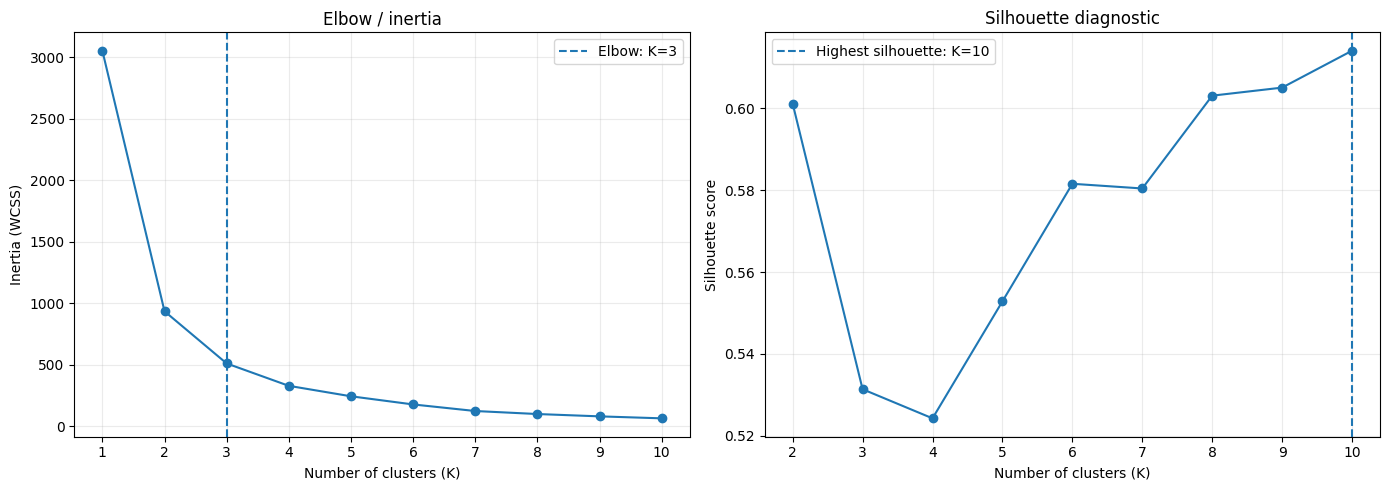

kmeans diagnostics complete. Advisory recommended n=2; choose n manually for the final fit.


,n,k,inertia,silhouette,elbow_strength,silhouette_strength,combined_score
0,1,1,3054.000000,NaN,0.000000,NaN,NaN
1,2,2,936.367680,0.601150,0.950945,0.855892,0.903419
2,3,3,512.280711,0.531372,1.000000,0.079182,0.539591
3,4,4,330.419426,0.524258,0.920059,0.000000,0.460029
4,5,5,245.441486,0.552844,0.788523,0.318189,0.553356
5,6,6,179.168727,0.581578,0.647026,0.638038,0.642532
6,7,7,125.743561,0.580432,0.498686,0.625276,0.561981
7,8,8,101.246455,0.603111,0.334942,0.877726,0.606334
8,9,9,82.327964,0.605079,0.168226,0.899634,0.533930
9,10,10,66.245767,0.614096,0.000000,1.000000,0.500000


Elbow k: 3
Silhouette k: 10
Combined internal best k: 2
SELECTED external-validation K (label-free): 2


In [16]:
# Diagnostics use ONLY the four post-KG coordinates; outcome labels are not passed here.
kdiag = model.diagnostics(
    "kmeans", positive_disease=DISEASE, min_clusters=2, max_clusters=10,
    variables=None, show=True, print_recommendations=True
)
display(kdiag)

elbow_k = kdiag.attrs.get("elbow_recommended_n")
silhouette_k = kdiag.attrs.get("silhouette_recommended_n")
combined_k = kdiag.attrs.get("best_k", kdiag.attrs.get("recommended_n"))

# Prespecified external-validation rule: use the combined INTERNAL diagnostic
# recommendation when available; otherwise fall back to silhouette.
BASELINE_K = int(combined_k if combined_k is not None else silhouette_k)

print("Elbow k:", elbow_k)
print("Silhouette k:", silhouette_k)
print("Combined internal best k:", combined_k)
print("SELECTED external-validation K (label-free):", BASELINE_K)

## 6. Label-free selected 4-D partition and retrospective external evaluation

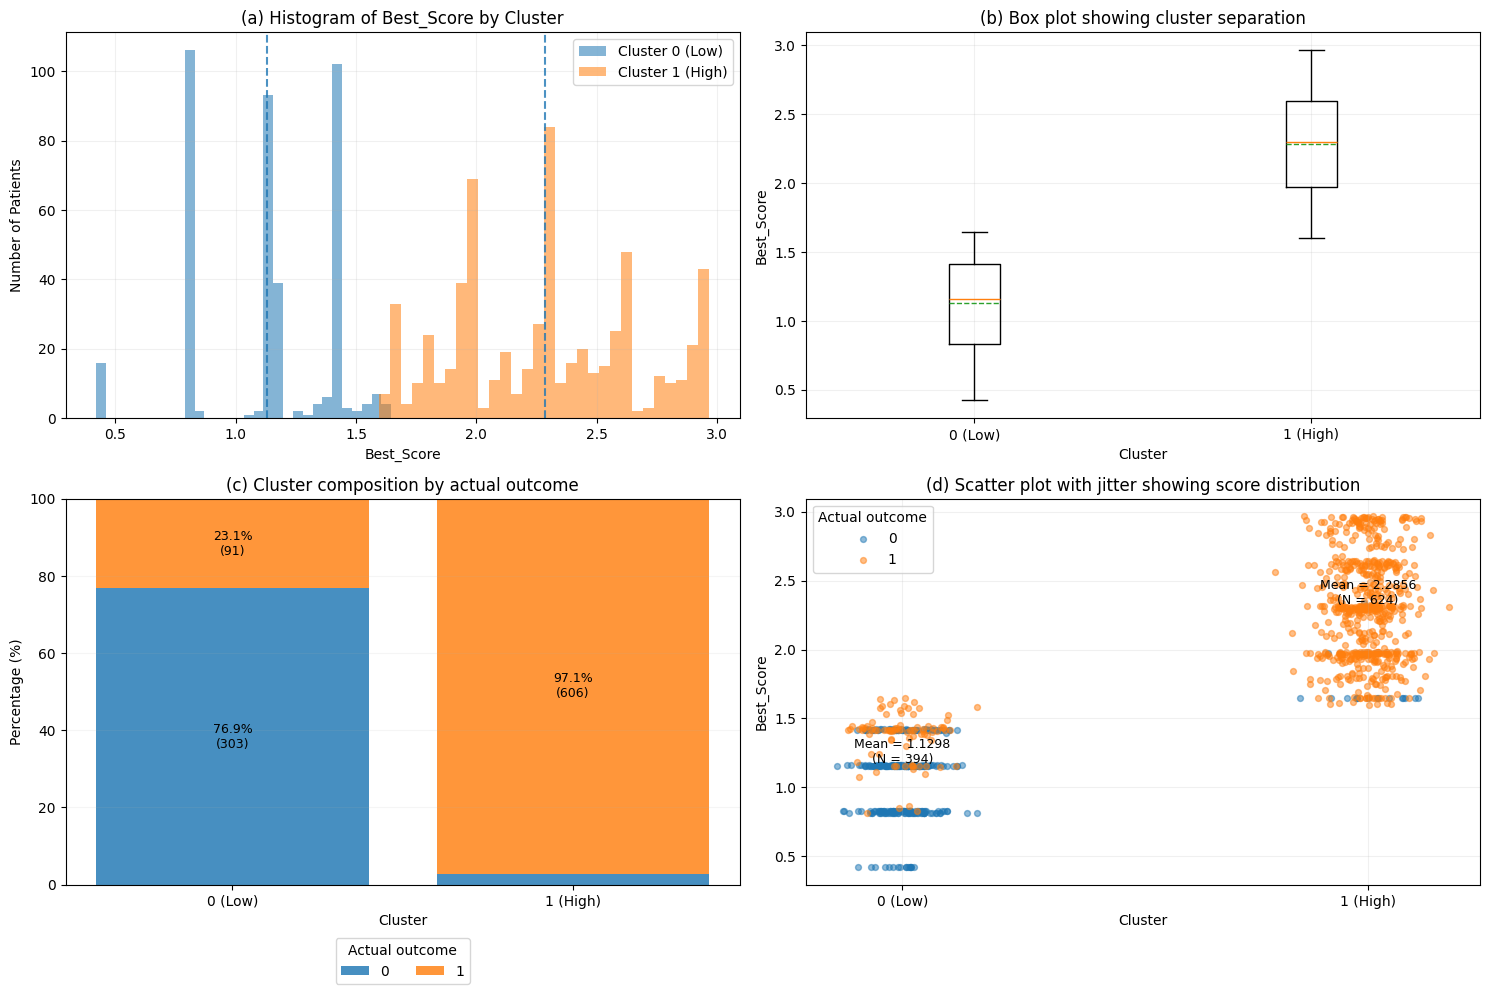

ALL-RECORD EVALUATION
{'n': 1018, 'accuracy': 0.8929273084479371, 'balanced_accuracy': np.float64(0.9066828463776666), 'precision_macro': 0.8700946895743851, 'recall_macro': 0.9066828463776666, 'f1_macro': 0.8825196000063524, 'f1_weighted': 0.8954347761582859, 'mcc': np.float64(0.7759153608103653), 'cohen_kappa': np.float64(0.7663574229031294), 'ground_truth_counts': {'positive': 697, 'negative': 321}, 'prediction_counts': {'positive': 624, 'negative': 394}, 'labels': ['negative', 'positive'], 'confusion_matrix': array([[303,  18],
       [ 91, 606]]), 'binary_label_order': ['negative', 'positive'], 'tn': 303, 'fp': 18, 'fn': 91, 'tp': 606, 'sensitivity': np.float64(0.8694404591104734), 'specificity': np.float64(0.9439252336448598), 'npv': np.float64(0.7690355329949239), 'ppv': np.float64(0.9711538461538461), 'f1_positive': 0.9174867524602573, 'f1': 0.9174867524602573, 'n_total': 1018, 'n_indeterminate': 0, 'coverage': 1.0, 'abstention_rate': 0.0, 'positive_disease': 'Dengue Fever', 't

In [17]:
from ckg_reasoner import KMeansPartition

km = model.partition(
    KMeansPartition(n_clusters=BASELINE_K, min_clusters=2, max_clusters=10,
                    random_state=RANDOM_STATE, n_init=20, variables=None),
    DISEASE, show=False
)
km.visualize(y_true=model.df_[TARGET])

result_all = model.evaluate(y_true=TARGET, positive_disease=DISEASE, positive_label=1, method=km)
result_selective = model.evaluate_tag(y_true=TARGET, positive_disease=DISEASE, positive_label=1, method=km)
print("ALL-RECORD EVALUATION")
print(result_all)
print("\nDECIDED/SUBSET EVALUATION")
print(result_selective)

## 7. Manuscript component ablation — post-KG representation

These experiments change only the coordinates supplied to K-means. They do **not** refit the diagnostic reasoner. The first six rows correspond to the manuscript table; `No CS` is an additional exploratory check.

In [18]:
import pandas as pd
import numpy as np
from sklearn.metrics import adjusted_rand_score

ABLATIONS = {
    "Full": None,  # variables=None => all four eligible coordinates
    "No P_evidence": ["r", "c", "Confidence_Score"],
    "No r": ["P_evidence", "c", "Confidence_Score"],
    "No c": ["P_evidence", "r", "Confidence_Score"],
    "P_evidence only": ["P_evidence"],
    "Profile only (r,c)": ["r", "c"],
    "No CS [exploratory]": ["P_evidence", "r", "c"],
}

def metric_value(d, *names):
    for n in names:
        if n in d: return d[n]
    return np.nan

baseline_tags = km.predictions_.astype(str)
rows=[]
partition_objects={}
for name, variables in ABLATIONS.items():
    part=model.partition(KMeansPartition(n_clusters=BASELINE_K, min_clusters=2, max_clusters=10,
                         random_state=RANDOM_STATE, n_init=20, variables=variables), DISEASE, show=False)
    partition_objects[name]=part
    allm=model.evaluate(y_true=TARGET, positive_disease=DISEASE, positive_label=1, method=part)
    selm=model.evaluate_tag(y_true=TARGET, positive_disease=DISEASE, positive_label=1, method=part)
    rows.append({
        "ablation":name, "variables":"ALL 4" if variables is None else ", ".join(variables),
        "ARI_vs_full":adjusted_rand_score(baseline_tags,part.predictions_.astype(str)),
        "accuracy_all":metric_value(allm,"accuracy"),
        "balanced_accuracy_all":metric_value(allm,"balanced_accuracy"),
        "MCC_all":metric_value(allm,"mcc","matthews_corrcoef"),
        "F1_positive_all":metric_value(allm,"f1_positive","f1"),
        "F1_positive_decided":metric_value(selm,"f1_positive","f1"),
        "coverage":metric_value(selm,"coverage"),
        "n_indeterminate":metric_value(selm,"n_indeterminate"),
    })
component_ablation=pd.DataFrame(rows)
display(component_ablation)

,ablation,variables,ARI_vs_full,accuracy_all,balanced_accuracy_all,MCC_all,F1_positive_all,F1_positive_decided,coverage,n_indeterminate
0,Full,ALL 4,1.000000,0.892927,0.906683,0.775915,0.917487,0.917487,1.0,0
1,No P_evidence,"r, c, Confidence_Score",0.560846,0.892927,0.853746,0.746435,0.924672,0.924672,1.0,0
2,No r,"P_evidence, c, Confidence_Score",0.949364,0.905697,0.916009,0.798857,0.928036,0.928036,1.0,0
3,No c,"P_evidence, r, Confidence_Score",0.941684,0.907662,0.917443,0.802465,0.929641,0.929641,1.0,0
4,P_evidence only,P_evidence,0.823316,0.911591,0.932917,0.821950,0.931298,0.931298,1.0,0
5,"Profile only (r,c)","r, c",0.560846,0.892927,0.853746,0.746435,0.924672,0.924672,1.0,0
6,No CS [exploratory],"P_evidence, r, c",1.000000,0.892927,0.906683,0.775915,0.917487,0.917487,1.0,0


## 8. K sensitivity and 20-seed stability

In [19]:
# K sensitivity (K=2,...,10) using all four coordinates.
k_rows=[]
for kval in K_RANGE:
    p=model.partition(KMeansPartition(n_clusters=kval,min_clusters=2,max_clusters=10,random_state=RANDOM_STATE,n_init=20,variables=None),DISEASE,show=False)
    a=model.evaluate(y_true=TARGET,positive_disease=DISEASE,positive_label=1,method=p)
    s=model.evaluate_tag(y_true=TARGET,positive_disease=DISEASE,positive_label=1,method=p)
    k_rows.append({"k":kval,"accuracy":metric_value(a,"accuracy"),"balanced_accuracy":metric_value(a,"balanced_accuracy"),
                   "f1_positive":metric_value(s,"f1_positive","f1"),"coverage":metric_value(s,"coverage")})
k_sensitivity=pd.DataFrame(k_rows)
display(k_sensitivity)

# Seed stability against seed-42 baseline.
seed_rows=[]
for seed in SEEDS:
    p=model.partition(KMeansPartition(n_clusters=BASELINE_K,min_clusters=2,max_clusters=10,random_state=seed,n_init=20,variables=None),DISEASE,show=False)
    s=model.evaluate_tag(y_true=TARGET,positive_disease=DISEASE,positive_label=1,method=p)
    seed_rows.append({"seed":seed,"ARI_vs_seed42":adjusted_rand_score(baseline_tags,p.predictions_.astype(str)),
                      "f1_positive":metric_value(s,"f1_positive","f1"),"coverage":metric_value(s,"coverage")})
seed_stability=pd.DataFrame(seed_rows)
display(seed_stability)

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics

,k,accuracy,balanced_accuracy,f1_positive,coverage
0,2,0.892927,0.906683,0.917487,1.000000
1,3,0.603143,0.642124,0.972692,0.623772
2,4,0.460707,0.437275,0.992888,0.465619
3,5,0.455796,0.433688,0.992785,0.460707
4,6,0.353635,0.271694,0.998549,0.354617
5,7,0.113949,0.096658,1.000000,0.113949
6,8,0.111002,0.094506,1.000000,0.111002
7,9,0.099214,0.085898,1.000000,0.099214
8,10,0.099214,0.085898,1.000000,0.099214


,seed,ARI_vs_seed42,f1_positive,coverage
0,0,1.0,0.917487,1.0
1,1,1.0,0.917487,1.0
2,2,1.0,0.917487,1.0
3,3,1.0,0.917487,1.0
4,4,1.0,0.917487,1.0
5,5,1.0,0.917487,1.0
6,6,1.0,0.917487,1.0
7,7,1.0,0.917487,1.0
8,8,1.0,0.917487,1.0
9,9,1.0,0.917487,1.0


## 9. Bootstrap uncertainty (1,000 nonparametric resamples)

This bootstraps the fixed baseline predictions; it does not refit K-means and therefore quantifies sampling uncertainty of the reported retrospective metrics.

In [20]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, matthews_corrcoef

truth=(model.df_[TARGET].astype(str).str.strip().str.lower().isin(["1","1.0","true","yes","positive","pos"])).astype(int).to_numpy()
pred_tag=km.predictions_.astype(str).to_numpy()
rng=np.random.default_rng(RANDOM_STATE)
boot=[]
for b in range(BOOTSTRAP_N):
    ix=rng.integers(0,len(truth),len(truth))
    yt=truth[ix]; pt=pred_tag[ix]
    yp=(pt=="positive").astype(int)
    decided=(pt!="indeterminate")
    row={"accuracy_all":accuracy_score(yt,yp),"coverage":decided.mean()}
    if len(np.unique(yt))>1:
        row["balanced_accuracy_all"]=balanced_accuracy_score(yt,yp)
        row["mcc_all"]=matthews_corrcoef(yt,yp)
    else:
        row["balanced_accuracy_all"]=np.nan; row["mcc_all"]=np.nan
    if decided.any(): row["f1_positive_decided"]=f1_score(yt[decided],yp[decided],zero_division=0)
    else: row["f1_positive_decided"]=np.nan
    boot.append(row)
bootstrap_df=pd.DataFrame(boot)
bootstrap_ci=bootstrap_df.quantile([0.025,0.5,0.975]).T.rename(columns={0.025:"CI_2.5%",0.5:"median",0.975:"CI_97.5%"})
display(bootstrap_ci)

,CI_2.5%,median,CI_97.5%
accuracy_all,0.874263,0.892927,0.911616
coverage,1.000000,1.000000,1.000000
balanced_accuracy_all,0.888662,0.906614,0.924455
mcc_all,0.735987,0.775372,0.814444
f1_positive_decided,0.901235,0.917464,0.933031


## 10. Reasoner-level ablations: contradiction and clinical importance

These rerun `graphfit()` after changing the encoded disease knowledge. They are intentionally separate from coordinate ablation.

In [21]:
from copy import deepcopy

def fresh_model_from_df(df_variant, knowledge_ablation=None):
    m=CKGModel()
    if knowledge_ablation is not None:
        for disease_key, refs in m.kb.reference_vectors.items():
            for _, ref in refs.items():
                if knowledge_ablation=="no_contradiction": ref["contradiction"]="None"
                elif knowledge_ablation=="importance_unity": ref["importance"]="Critical"  # encoded value 1.0
    m.hmap(df_variant.copy(),interactive=False)
    m.graphfit(strategy="exhaustive")
    return m

def run_model_partition(m, k=BASELINE_K):
    p=m.partition(KMeansPartition(n_clusters=k,min_clusters=2,max_clusters=10,random_state=RANDOM_STATE,n_init=20,variables=None),DISEASE,show=False)
    a=m.evaluate(y_true=TARGET,positive_disease=DISEASE,positive_label=1,method=p)
    s=m.evaluate_tag(y_true=TARGET,positive_disease=DISEASE,positive_label=1,method=p)
    return p,a,s

knowledge_rows=[]
for abl in ["no_contradiction","importance_unity"]:
    m2=fresh_model_from_df(df,abl)
    p,a,s=run_model_partition(m2)
    knowledge_rows.append({"ablation":abl,"ARI_vs_full":adjusted_rand_score(baseline_tags,p.predictions_.astype(str)),
        "accuracy_all":metric_value(a,"accuracy"),"f1_positive_decided":metric_value(s,"f1_positive","f1"),"coverage":metric_value(s,"coverage")})
knowledge_ablation=pd.DataFrame(knowledge_rows)
display(knowledge_ablation)

Successful matches found: 8 dataset headings mapped to ontology headings.
dataset_heading   ontology_heading
 Platelet Count MTP_platelet_count
      WBC Count            LEU_wbc
          Fever                FEV
 Fever Duration        FEV_dura_dy
       Headache                HDH
        Myalgia                MYA
           Rash                RSH
       Vomiting                VOM
Ignored metadata/target headings: ['id', 'Gender', 'Age', 'Outcome']
Graph fitting completed for 1018 record(s); strategy='exhaustive'; knowledge base=3 disease graph(s).
Auto K-means completed on S0=[P_evidence, r, c, Confidence_Score] (optimal K=8; target ordering=Influenza).
Successful matches found: 8 dataset headings mapped to ontology headings.
dataset_heading   ontology_heading
 Platelet Count MTP_platelet_count
      WBC Count            LEU_wbc
          Fever                FEV
 Fever Duration        FEV_dura_dy
       Headache                HDH
        Myalgia                MYA
           Ra

,ablation,ARI_vs_full,accuracy_all,f1_positive_decided,coverage
0,no_contradiction,0.976487,0.887033,0.912548,1.0
1,importance_unity,0.988206,0.891945,0.916667,1.0


## 11. Evidence-gate parameter sensitivity

One parameter family is varied at a time around the frozen baseline (α=0.05, β=10, γ=0.85). This is a controlled runtime patch for sensitivity analysis only; it does **not** modify the installed package files.

In [22]:
import math, contextlib
import ckg_reasoner.functions as ckg_functions
import ckg_reasoner.reasoning as ckg_reasoning

@contextlib.contextmanager
def temporary_gate(alpha=0.05,beta=10.0,gamma=0.85):
    old_fun=ckg_functions.manuscript_evidence_contributions
    old_reason=ckg_reasoning.manuscript_evidence_contributions
    def contrib(*,information_gate,diagnostic_role,importance,support,contradiction):
        def fgate(x):
            x=float(np.clip(x,0,1)); return 1.0/(1.0+alpha*math.exp(-beta*(x-gamma)))
        ig=float(np.clip(information_gate,0,1))
        return (fgate(ig)*max(float(diagnostic_role),0.0)*float(importance)*max(float(support),0.0),
                fgate(1.0-ig)*abs(float(contradiction)))
    ckg_functions.manuscript_evidence_contributions=contrib
    ckg_reasoning.manuscript_evidence_contributions=contrib
    try: yield
    finally:
        ckg_functions.manuscript_evidence_contributions=old_fun
        ckg_reasoning.manuscript_evidence_contributions=old_reason

gate_settings=[("baseline",0.05,10,0.85)]
gate_settings += [(f"alpha={x}",x,10,0.85) for x in [0.025,0.10]]
gate_settings += [(f"beta={x}",0.05,x,0.85) for x in [5,20]]
gate_settings += [(f"gamma={x}",0.05,10,x) for x in [0.75,0.95]]
gate_rows=[]
for name,a,b,g in gate_settings:
    with temporary_gate(a,b,g):
        mg=fresh_model_from_df(df)
        p,am,sm=run_model_partition(mg)
    gate_rows.append({"setting":name,"alpha":a,"beta":b,"gamma":g,"ARI_vs_full":adjusted_rand_score(baseline_tags,p.predictions_.astype(str)),
                      "f1_positive_decided":metric_value(sm,"f1_positive","f1"),"coverage":metric_value(sm,"coverage")})
gate_sensitivity=pd.DataFrame(gate_rows)
display(gate_sensitivity)

Successful matches found: 8 dataset headings mapped to ontology headings.
dataset_heading   ontology_heading
 Platelet Count MTP_platelet_count
      WBC Count            LEU_wbc
          Fever                FEV
 Fever Duration        FEV_dura_dy
       Headache                HDH
        Myalgia                MYA
           Rash                RSH
       Vomiting                VOM
Ignored metadata/target headings: ['id', 'Gender', 'Age', 'Outcome']
Graph fitting completed for 1018 record(s); strategy='exhaustive'; knowledge base=3 disease graph(s).
Auto K-means completed on S0=[P_evidence, r, c, Confidence_Score] (optimal K=8; target ordering=Influenza).
Successful matches found: 8 dataset headings mapped to ontology headings.
dataset_heading   ontology_heading
 Platelet Count MTP_platelet_count
      WBC Count            LEU_wbc
          Fever                FEV
 Fever Duration        FEV_dura_dy
       Headache                HDH
        Myalgia                MYA
           Ra

,setting,alpha,beta,gamma,ARI_vs_full,f1_positive_decided,coverage
0,baseline,0.050,10,0.85,1.000000,0.917487,1.0
1,alpha=0.025,0.025,10,0.85,1.000000,0.917487,1.0
2,alpha=0.1,0.100,10,0.85,0.996061,0.918306,1.0
3,beta=5,0.050,5,0.85,0.984288,0.919123,1.0
4,beta=20,0.050,20,0.85,0.992129,0.917487,1.0
5,gamma=0.75,0.050,10,0.75,0.996061,0.918306,1.0
6,gamma=0.95,0.050,10,0.95,0.992129,0.917487,1.0


## 12. Controlled random evidence withholding

A fixed random seed masks 10%, 25%, and 50% of observed non-target patient fields and reruns the entire reasoner without refitting ontology weights. Adjust `PROTECTED_COLUMNS` if your local dataset contains additional administrative/non-evidence fields.

In [23]:
PROTECTED_COLUMNS={TARGET,"id","ID","Id","Record_ID","record_id"}
evidence_cols=[c for c in df.columns if c not in PROTECTED_COLUMNS]
withhold_rows=[]
for frac in WITHHOLD_FRACTIONS:
    dfx=df.copy(); rng=np.random.default_rng(RANDOM_STATE+int(frac*100))
    vals=dfx[evidence_cols]
    observed=vals.notna().to_numpy(); draw=rng.random(observed.shape)<frac
    mask=observed & draw
    dfx.loc[:,evidence_cols]=vals.mask(mask)
    mw=fresh_model_from_df(dfx)
    p,am,sm=run_model_partition(mw)
    withhold_rows.append({"withheld_fraction":frac,"actually_masked":int(mask.sum()),"ARI_vs_full":adjusted_rand_score(baseline_tags,p.predictions_.astype(str)),
                          "accuracy_all":metric_value(am,"accuracy"),"balanced_accuracy_all":metric_value(am,"balanced_accuracy"),
                          "MCC_all":metric_value(am,"mcc","matthews_corrcoef"),"f1_positive_decided":metric_value(sm,"f1_positive","f1"),"coverage":metric_value(sm,"coverage")})
evidence_withholding=pd.DataFrame(withhold_rows)
display(evidence_withholding)

/tmp/ipykernel_4755/1040261658.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[16. 25. 32. ... 32. nan 43.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dfx.loc[:,evidence_cols]=vals.mask(mask)
/tmp/ipykernel_4755/1040261658.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[149134.  85943. 285134. ... 281872.     nan 281658.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dfx.loc[:,evidence_cols]=vals.mask(mask)
/tmp/ipykernel_4755/1040261658.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[   nan    nan 11000. ... 12949.    nan 11751.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dfx.loc[:,evidence_cols]=vals.mask(mask)
/tmp/ipyke

Successful matches found: 8 dataset headings mapped to ontology headings.
dataset_heading   ontology_heading
 Platelet Count MTP_platelet_count
      WBC Count            LEU_wbc
          Fever                FEV
 Fever Duration        FEV_dura_dy
       Headache                HDH
        Myalgia                MYA
           Rash                RSH
       Vomiting                VOM
Ignored metadata/target headings: ['id', 'Gender', 'Age', 'Outcome']
Graph fitting completed for 1018 record(s); strategy='exhaustive'; knowledge base=3 disease graph(s).
Auto K-means completed on S0=[P_evidence, r, c, Confidence_Score] (optimal K=10; target ordering=Influenza).


/tmp/ipykernel_4755/1040261658.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[nan nan 32. ... 32. 21. nan]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dfx.loc[:,evidence_cols]=vals.mask(mask)
/tmp/ipykernel_4755/1040261658.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[149134.  85943. 285134. ... 281872. 111015.     nan]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dfx.loc[:,evidence_cols]=vals.mask(mask)
/tmp/ipykernel_4755/1040261658.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 4468.  7050. 11000. ... 12949.  4083. 11751.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dfx.loc[:,evidence_cols]=vals.mask(mask)
/tmp/ipyke

Successful matches found: 8 dataset headings mapped to ontology headings.
dataset_heading   ontology_heading
 Platelet Count MTP_platelet_count
      WBC Count            LEU_wbc
          Fever                FEV
 Fever Duration        FEV_dura_dy
       Headache                HDH
        Myalgia                MYA
           Rash                RSH
       Vomiting                VOM
Ignored metadata/target headings: ['id', 'Gender', 'Age', 'Outcome']
Graph fitting completed for 1018 record(s); strategy='exhaustive'; knowledge base=3 disease graph(s).
Auto K-means completed on S0=[P_evidence, r, c, Confidence_Score] (optimal K=10; target ordering=Influenza).


/tmp/ipykernel_4755/1040261658.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[nan nan 32. ... 32. nan 43.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dfx.loc[:,evidence_cols]=vals.mask(mask)
/tmp/ipykernel_4755/1040261658.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[    nan     nan 285134. ...     nan     nan     nan]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dfx.loc[:,evidence_cols]=vals.mask(mask)
/tmp/ipykernel_4755/1040261658.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[   nan    nan 11000. ...    nan    nan    nan]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dfx.loc[:,evidence_cols]=vals.mask(mask)
/tmp/ipyke

Successful matches found: 8 dataset headings mapped to ontology headings.
dataset_heading   ontology_heading
 Platelet Count MTP_platelet_count
      WBC Count            LEU_wbc
          Fever                FEV
 Fever Duration        FEV_dura_dy
       Headache                HDH
        Myalgia                MYA
           Rash                RSH
       Vomiting                VOM
Ignored metadata/target headings: ['id', 'Gender', 'Age', 'Outcome']
Graph fitting completed for 1018 record(s); strategy='exhaustive'; knowledge base=3 disease graph(s).
Auto K-means completed on S0=[P_evidence, r, c, Confidence_Score] (optimal K=10; target ordering=Influenza).


,withheld_fraction,actually_masked,ARI_vs_full,accuracy_all,balanced_accuracy_all,MCC_all,f1_positive_decided,coverage
0,0.10,1019,0.801632,0.897839,0.901027,0.776155,0.922849,1.0
1,0.25,2579,0.605996,0.867387,0.857782,0.700955,0.901244,1.0
2,0.50,5135,0.375710,0.811395,0.781601,0.563201,0.862267,1.0


## 13. Export manuscript experiment tables

In [24]:
from pathlib import Path
RESULT_DIR=Path("/content/drive/MyDrive/CKG/Results")
RESULT_DIR.mkdir(parents=True,exist_ok=True)
OUT=RESULT_DIR/"F_Dengue_D3_1018"
OUT.mkdir(parents=True,exist_ok=True)
component_ablation.to_csv(OUT/"component_ablation.csv",index=False)
k_sensitivity.to_csv(OUT/"k_sensitivity.csv",index=False)
seed_stability.to_csv(OUT/"seed_stability.csv",index=False)
bootstrap_ci.to_csv(OUT/"bootstrap_95CI.csv")
knowledge_ablation.to_csv(OUT/"knowledge_ablation.csv",index=False)
gate_sensitivity.to_csv(OUT/"gate_sensitivity.csv",index=False)
evidence_withholding.to_csv(OUT/"evidence_withholding.csv",index=False)
kdiag.to_csv(OUT/"kmeans_internal_diagnostics.csv",index=False)
with open(OUT/"selected_k.txt","w") as f:
    f.write(f"label_free_selected_k={BASELINE_K}\n")
    f.write(f"elbow_k={elbow_k}\n")
    f.write(f"silhouette_k={silhouette_k}\n")
    f.write(f"combined_k={combined_k}\n")
print("Saved external-validation experiment tables to:",OUT)

Saved external-validation experiment tables to: /content/drive/MyDrive/CKG/Results/F_Dengue_D3_1018


## 14. Original explainability / FOL / output cells (preserved)

In [25]:
# Optional: full-cohort FOL/report generation can be expensive and very verbose.
# Uncomment only when you specifically need record-level reports for every patient.
# for idx in range(len(model.df_)):
#     model.explain("Dengue", row=idx, format="fol")
#     model.explainable_layer("Dengue", row=idx, format="report")
print("Full-cohort FOL export skipped by default; single-record explainability remains available below.")

Full-cohort FOL export skipped by default; single-record explainability remains available below.


In [26]:
result_all = model.evaluate(
    y_true=TARGET, positive_disease=DISEASE, positive_label=1, method=km
)
result_all

{'n': 1018,
 'accuracy': 0.8929273084479371,
 'balanced_accuracy': np.float64(0.9066828463776666),
 'precision_macro': 0.8700946895743851,
 'recall_macro': 0.9066828463776666,
 'f1_macro': 0.8825196000063524,
 'f1_weighted': 0.8954347761582859,
 'mcc': np.float64(0.7759153608103653),
 'cohen_kappa': np.float64(0.7663574229031294),
 'ground_truth_counts': {'positive': 697, 'negative': 321},
 'prediction_counts': {'positive': 624, 'negative': 394},
 'labels': ['negative', 'positive'],
 'confusion_matrix': array([[303,  18],
        [ 91, 606]]),
 'binary_label_order': ['negative', 'positive'],
 'tn': 303,
 'fp': 18,
 'fn': 91,
 'tp': 606,
 'sensitivity': np.float64(0.8694404591104734),
 'specificity': np.float64(0.9439252336448598),
 'npv': np.float64(0.7690355329949239),
 'ppv': np.float64(0.9711538461538461),
 'f1_positive': 0.9174867524602573,
 'f1': 0.9174867524602573,
 'n_total': 1018,
 'n_indeterminate': 0,
 'coverage': 1.0,
 'abstention_rate': 0.0,
 'positive_disease': 'Dengue Fev

In [27]:
result_selective = model.evaluate_tag(
    y_true=TARGET, positive_disease=DISEASE, positive_label=1, method=km
)
result_selective

{'n': 1018,
 'accuracy': 0.8929273084479371,
 'balanced_accuracy': np.float64(0.9066828463776666),
 'precision_macro': 0.8700946895743851,
 'recall_macro': 0.9066828463776666,
 'f1_macro': 0.8825196000063524,
 'f1_weighted': 0.8954347761582859,
 'mcc': np.float64(0.7759153608103653),
 'cohen_kappa': np.float64(0.7663574229031294),
 'ground_truth_counts': {'1': 697, '0': 321},
 'prediction_counts': {'1': 624, '0': 394},
 'labels': ['0', '1'],
 'confusion_matrix': array([[303,  18],
        [ 91, 606]]),
 'binary_label_order': ['0', '1'],
 'tn': 303,
 'fp': 18,
 'fn': 91,
 'tp': 606,
 'sensitivity': np.float64(0.8694404591104734),
 'specificity': np.float64(0.9439252336448598),
 'npv': np.float64(0.7690355329949239),
 'ppv': np.float64(0.9711538461538461),
 'f1_positive': 0.9174867524602573,
 'f1': 0.9174867524602573,
 'roc_auc': np.float64(0.9675824740655322),
 'average_precision': np.float64(0.984663200319912),
 'log_loss': 0.3838073640802619,
 'n_total': 1018,
 'n_indeterminate': 0,
 

In [28]:
!pip install -q XlsxWriter
output_path = "/content/drive/MyDrive/CKG/Results/CKG_D3_Dengue_1018_FrozenValidation.xlsx"
model.output(output_path, positive_disease=DISEASE, method=km)
print("Saved:", output_path)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 4.6 MB/s eta 0:00:00
Output written: /content/drive/MyDrive/CKG/Results/CKG_D3_Dengue_1018_FrozenValidation.xlsx (method=kmeans); mismatch rows are yellow when actual outcome is available.
Saved: /content/drive/MyDrive/CKG/Results/CKG_D3_Dengue_1018_FrozenValidation.xlsx


In [29]:
print("\n" + "=" * 70)
print("ALL-RECORD RETROSPECTIVE EXTERNAL EVALUATION")
print("=" * 70)
for metric, value in result_all.items(): print(f"{metric}: {value}")
print("\n" + "=" * 70)
print("DECIDED/SUBSET RETROSPECTIVE EXTERNAL EVALUATION")
print("=" * 70)
for metric, value in result_selective.items(): print(f"{metric}: {value}")
print("\nK was selected without outcome labels:", BASELINE_K)


ALL-RECORD RETROSPECTIVE EXTERNAL EVALUATION
n: 1018
accuracy: 0.8929273084479371
balanced_accuracy: 0.9066828463776666
precision_macro: 0.8700946895743851
recall_macro: 0.9066828463776666
f1_macro: 0.8825196000063524
f1_weighted: 0.8954347761582859
mcc: 0.7759153608103653
cohen_kappa: 0.7663574229031294
ground_truth_counts: {'positive': 697, 'negative': 321}
prediction_counts: {'positive': 624, 'negative': 394}
labels: ['negative', 'positive']
confusion_matrix: [[303  18]
 [ 91 606]]
binary_label_order: ['negative', 'positive']
tn: 303
fp: 18
fn: 91
tp: 606
sensitivity: 0.8694404591104734
specificity: 0.9439252336448598
npv: 0.7690355329949239
ppv: 0.9711538461538461
f1_positive: 0.9174867524602573
f1: 0.9174867524602573
n_total: 1018
n_indeterminate: 0
coverage: 1.0
abstention_rate: 0.0
positive_disease: Dengue Fever
tag_method: kmeans
evaluation_mode: all records; indeterminate retained as a third predicted label

DECIDED/SUBSET RETROSPECTIVE EXTERNAL EVALUATION
n: 1018
accuracy: 0

In [30]:
idx = 0
print("Row:", idx)
print("\n=== SCORE / EVIDENCE ===")
print(model.evidence(DISEASE, row=idx))
print("\n=== FOL ===")
print(model.explain(DISEASE, row=idx, format="fol"))

Row: 0

=== SCORE / EVIDENCE ===
{'Dengue Fever':               feature                           name  clinical_importance  \
0      LEU_laboratory                     Leukopenia                  1.0   
1      MTP_laboratory          Mild Thrombocytopenia                  1.0   
2   FEV_manifestation                          Fever                  1.0   
3   HDH_manifestation                       Headache                  0.7   
4   MYA_manifestation                        Myalgia                  0.7   
..                ...                            ...                  ...   
62       MYC_severity                    Myocarditis                  1.0   
63       RFL_severity            Respiratory Failure                  1.0   
64       STP_severity        Severe Thrombocytopenia                  1.0   
65       SLW_severity              Severe Leukopenia                  0.7   
66       EXH_severity  Extremely Elevated Hematocrit                  1.0   

    diagnostic_role  pati

In [31]:
idx = 0
print("Row:", idx)
print("\n=== EVIDENCE / DISEASE SCORE / SIMILARITY ===")
print(model.evidence(DISEASE, row=idx))
print("\n=== CONTINUOUS REASONING ===")
print(model.Continuous_reasoning(DISEASE, row=idx))
print("\n=== DETERMINISTIC REASONING ===")
print(model.Deterministic_reasoning(DISEASE, row=idx))
print("\n=== UNCERTAINTY ===")
print(model.Uncertainty(DISEASE, row=idx))
print("\n=== FOL ===")
print(model.explain(DISEASE, row=idx, format="fol"))

Row: 0

=== EVIDENCE / DISEASE SCORE / SIMILARITY ===
{'Dengue Fever':               feature                           name  clinical_importance  \
0      LEU_laboratory                     Leukopenia                  1.0   
1      MTP_laboratory          Mild Thrombocytopenia                  1.0   
2   FEV_manifestation                          Fever                  1.0   
3   HDH_manifestation                       Headache                  0.7   
4   MYA_manifestation                        Myalgia                  0.7   
..                ...                            ...                  ...   
62       MYC_severity                    Myocarditis                  1.0   
63       RFL_severity            Respiratory Failure                  1.0   
64       STP_severity        Severe Thrombocytopenia                  1.0   
65       SLW_severity              Severe Leukopenia                  0.7   
66       EXH_severity  Extremely Elevated Hematocrit                  1.0   

    

In [32]:
scores = model.disease_scores()
print(scores)
row_scores = scores.iloc[0].sort_values(ascending=False)
print(row_scores)

for rank, (disease, score) in enumerate(row_scores.items(), start=1):
    print(f"Rank {rank}: {disease} = {score:.6f}")

        Influenza  Dengue Fever   Malaria
row_id                                   
0        0.738662      0.655737  0.653572
1        0.986059      0.772694  0.921833
2        0.560009      0.387938  0.000000
3        0.384900      0.384900  0.588416
4        0.725861      0.656452  0.618713
...           ...           ...       ...
1013     0.999819      0.877773  0.957443
1014     0.986059      0.658082  0.921833
1015     0.507497      0.276461  0.471405
1016     0.732093      0.755422  0.623589
1017     0.732831      0.471405  0.649011

[1018 rows x 3 columns]
Influenza       0.738662
Dengue Fever    0.655737
Malaria         0.653572
Name: 0, dtype: float64
Rank 1: Influenza = 0.738662
Rank 2: Dengue Fever = 0.655737
Rank 3: Malaria = 0.653572
